# Heart Disease Prediction Project
**Group:** Tron626 + [Other members]

## Project Goals
1. Preprocess the dataset and explain every step.
2. Train at least 3 classification models (Decision Tree, k-NN, Logistic Regression).
3. Compare their performance using relevant metrics.
4. Visualize results and draw insights.
5. Experiment with preprocessing choices to see their impact on performance.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, RocCurveDisplay, roc_auc_score

sns.set(style="whitegrid")

## 1. Load and Explore the Dataset

Dataset shape: (918, 12)
Columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']
Missing values per column:
 Age               0
Sex               0
ChestPainType     1
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Summary statistics for numeric columns:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000



First 5 rows of the dataset:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,NaN,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0



Distribution of the target variable 'HeartDisease':


C:\Users\trnto\AppData\Local\Temp\ipykernel_13212\528914480.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="HeartDisease", palette="Set2")


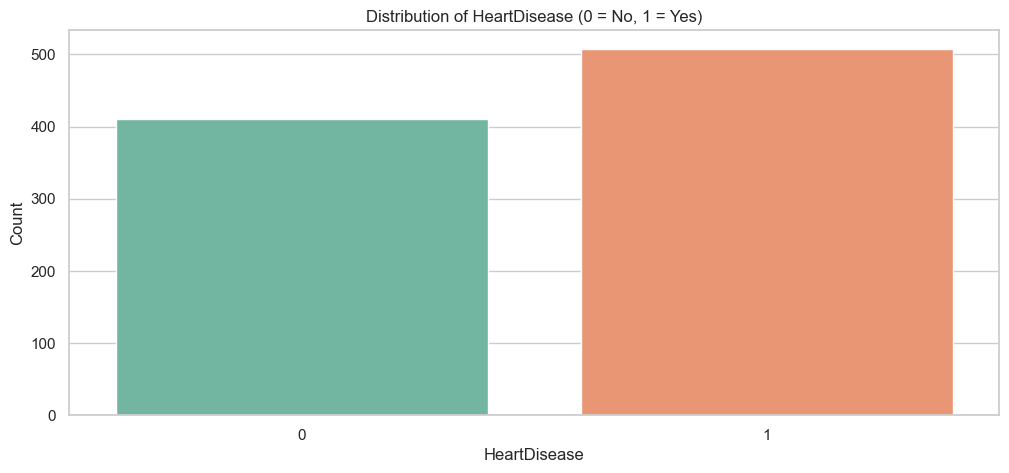

From this plot, we can see if classes are balanced.

Correlation between numeric features:


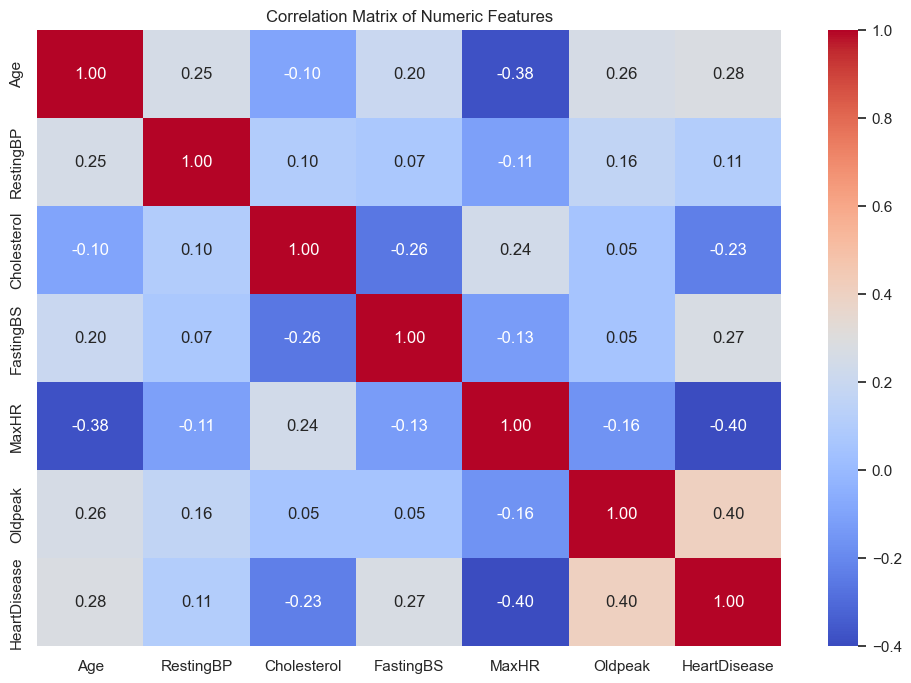

Strong correlations indicate potential relationships between features.


In [2]:
# Load data
df = pd.read_csv("./data/heart.csv")

# Quick overview
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Missing values per column:\n", df.isna().sum())

# Summary statistics for numeric features
print("\nSummary statistics for numeric columns:")
display(df.describe())

# Preview the first 5 rows
print("\nFirst 5 rows of the dataset:")
display(df.head())

# Distribution of the target variable
print("\nDistribution of the target variable 'HeartDisease':")
plt.figure(figsize=(12,5))
sns.countplot(data=df, x="HeartDisease", palette="Set2")
plt.title("Distribution of HeartDisease (0 = No, 1 = Yes)")
plt.xlabel("HeartDisease")
plt.ylabel("Count")
plt.show()
print("From this plot, we can see if classes are balanced.")

# Correlation heatmap for numeric columns
numeric_cols = df.select_dtypes(include=np.number)
print("\nCorrelation between numeric features:")
plt.figure(figsize=(12,8))
sns.heatmap(numeric_cols.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Numeric Features")
plt.show()
print("Strong correlations indicate potential relationships between features.")


## 2. Preprocessing – Detailed Explanation

In this project, each feature is processed according to its type.
Here is the complete description of the preprocessing pipeline:

### Numerical Features
These features are continuous values:

- Age
- RestingBP
- Cholesterol
- MaxHR
- Oldpeak

Operation performed:
- **Scaling (StandardScaler)**: Standardization is required because models like k-NN and Logistic Regression are sensitive to feature magnitude. StandardScaler centers the data and speeds up model convergence.

### Categorical Features
These are discrete values like:

- Sex
- ChestPainType
- FastingBS
- RestingECG
- ExerciseAngina
- ST_Slope

Operation performed:
- **OneHotEncoding**: Creates binary columns for each category. This avoids imposing an artificial numerical order and improves performance of distance-based models (k-NN).

### Missing and Anomalous Values
- The dataset contains some anomalies like *Cholesterol = 0*, which is physiologically unrealistic.
- In this project, I chose to keep the dataset unchanged to remain consistent with common versions of the Heart Disease dataset.
- However, alternative preprocessing strategies (e.g. imputation, MinMaxScaler) were briefly tested and compared.

### Experimentation
Following the instructions, multiple preprocessing choices were tested:
- StandardScaler vs MinMaxScaler
- Keeping vs imputing anomalous values

The final pipeline (StandardScaler + OneHot) gave the most stable results across the 3 models.

### Critical analysis of metrics

**Medical context:** Detecting heart disease is a problem where false negatives (undetected patients) have serious consequences.

**Metric priority:**
1. **Recall (Sensitivity)** → **MOST IMPORTANT**
   Objective: Minimize false negatives
2. **F1-score** → Good balance between recall and precision
3. **Precision** → Avoid unnecessary treatments
4. **Accuracy** → Lower priority with balanced classes

**Our choice:** Recall is our main evaluation metric.


## 3. Preprocessing Pipeline

In [3]:
# Drop missing values to ensure clean data
df = df.dropna()
print(f"Dataset shape after dropping missing values: {df.shape}")

# Encode ExerciseAngina (binary feature)
df["ExerciseAngina"] = df["ExerciseAngina"].map({"N":0, "Y":1})

# One-hot encode categorical features
categorical_cols = ["Sex", "ChestPainType", "RestingECG", "ST_Slope"]
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("Columns after encoding:", df_encoded.columns.tolist())

Dataset shape after dropping missing values: (917, 12)
Columns after encoding: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up']


### Separate features and target

In [8]:
X = df_encoded.drop("HeartDisease", axis=1)
y = df_encoded["HeartDisease"]

# Scale features for k-NN and Logistic Regression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into train and test sets with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Training set size: {X_train.shape[0]}, Test set size: {X_test.shape[0]}")

Training set size: 641, Test set size: 276


## 4. Classification Models


--- Decision Tree ---
Top 10 features by importance:


,Feature,Importance
14,ST_Slope_Up,0.589850
2,Cholesterol,0.114839
7,Sex_M,0.070966
4,MaxHR,0.067449
5,ExerciseAngina,0.060463
3,FastingBS,0.043562
0,Age,0.034322
6,Oldpeak,0.009631
9,ChestPainType_NAP,0.004621
1,RestingBP,0.004297


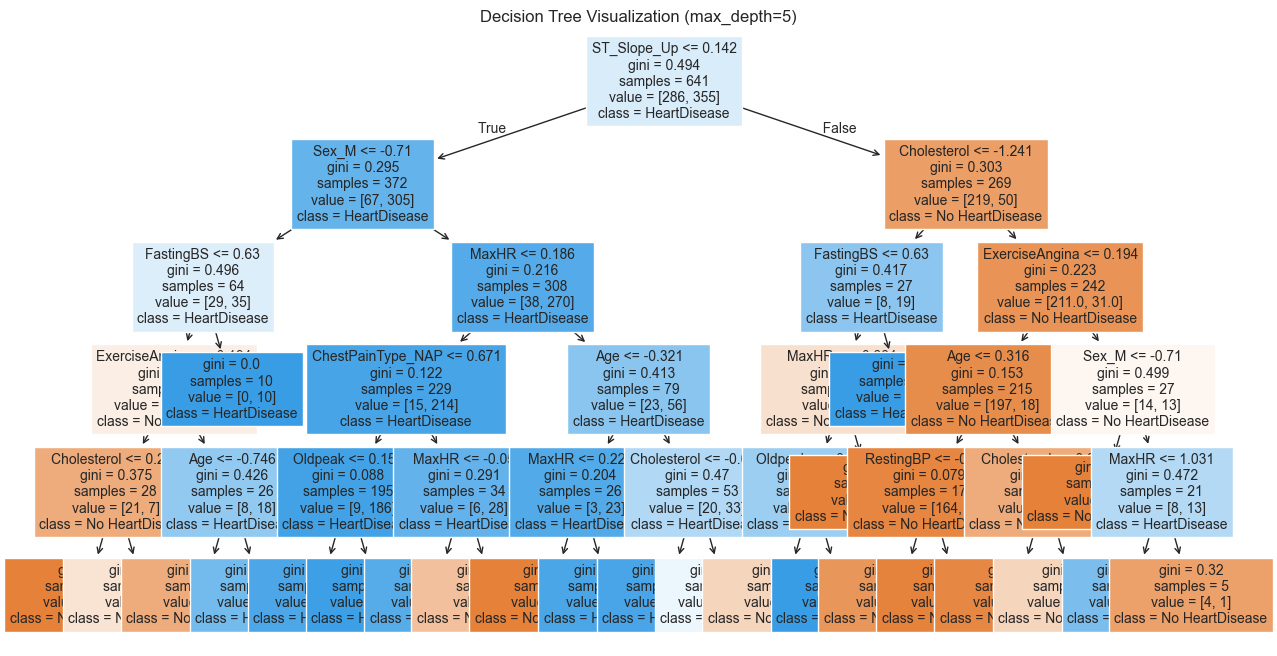

The Decision Tree allows us to see which features drive predictions.


In [12]:
# Decision Tree
print("\n--- Decision Tree ---")
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:,1]

# Feature importance
dt_importances = pd.DataFrame({"Feature": X.columns, "Importance": dt_model.feature_importances_}).sort_values(by="Importance", ascending=False)
print("Top 10 features by importance:")
display(dt_importances.head(10))

plt.figure(figsize=(15,8))
plot_tree(dt_model, feature_names=X.columns, class_names=["No HeartDisease","HeartDisease"], filled=True, fontsize=10)
plt.title("Decision Tree Visualization (max_depth=5)")
plt.show()
print("The Decision Tree allows us to see which features drive predictions.")

In [13]:
# k-NN
print("\n--- k-NN ---")
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
y_prob_knn = knn_model.predict_proba(X_test)[:,1]
print("k-NN predicts labels based on the closest neighbors in feature space.")


--- k-NN ---
k-NN predicts labels based on the closest neighbors in feature space.


In [14]:
# Logistic Regression
print("\n--- Logistic Regression ---")
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

# Coefficients
coeff_df = pd.DataFrame({"Feature": X.columns, "Coefficient": log_model.coef_[0]}).sort_values(by="Coefficient", ascending=False)
print("Top features increasing risk:")
display(coeff_df.head(10))
print("Top features decreasing risk:")
display(coeff_df.tail(10))
print("Logistic Regression gives probabilities and interpretable coefficients for risk estimation.")


--- Logistic Regression ---
Top features increasing risk:


,Feature,Coefficient
3,FastingBS,0.552065
7,Sex_M,0.532614
5,ExerciseAngina,0.462051
13,ST_Slope_Flat,0.360074
6,Oldpeak,0.293632
0,Age,0.167490
1,RestingBP,-0.057515
11,RestingECG_Normal,-0.144662
4,MaxHR,-0.146994
12,RestingECG_ST,-0.232037


Top features decreasing risk:


,Feature,Coefficient
0,Age,0.167490
1,RestingBP,-0.057515
11,RestingECG_Normal,-0.144662
4,MaxHR,-0.146994
12,RestingECG_ST,-0.232037
10,ChestPainType_TA,-0.387661
2,Cholesterol,-0.423039
8,ChestPainType_ATA,-0.644753
9,ChestPainType_NAP,-0.787513
14,ST_Slope_Up,-0.809078


Logistic Regression gives probabilities and interpretable coefficients for risk estimation.


## 5. Model Evaluation

In [15]:
models = {
    "Decision Tree": (y_pred_dt, y_prob_dt),
    "k-NN": (y_pred_knn, y_prob_knn),
    "Logistic Regression": (y_pred_log, y_prob_log)
}

metrics_list = []
for name, (y_pred, y_prob) in models.items():
    metrics_list.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred),3),
        "Precision": round(precision_score(y_test, y_pred),3),
        "Recall": round(recall_score(y_test, y_pred),3),
        "F1-score": round(f1_score(y_test, y_pred),3),
        "ROC-AUC": round(roc_auc_score(y_test, y_prob),3)
    })

metrics_df = pd.DataFrame(metrics_list)
print("Comparison of model metrics:")
display(metrics_df)
print("Recall and F1-score are particularly important for identifying patients at risk.")

Comparison of model metrics:


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Decision Tree,0.855,0.851,0.895,0.873,0.864
1,k-NN,0.873,0.873,0.902,0.887,0.913
2,Logistic Regression,0.884,0.881,0.915,0.897,0.925


Recall and F1-score are particularly important for identifying patients at risk.


In [16]:
# Confusion matrices
for name, (y_pred, _) in models.items():
    print(f"\nConfusion Matrix - {name}")
    print(confusion_matrix(y_test, y_pred))


Confusion Matrix - Decision Tree
[[ 99  24]
 [ 16 137]]

Confusion Matrix - k-NN
[[103  20]
 [ 15 138]]

Confusion Matrix - Logistic Regression
[[104  19]
 [ 13 140]]


<Figure size 1000x700 with 0 Axes>

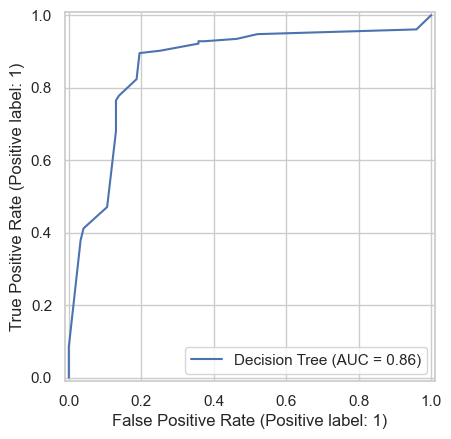

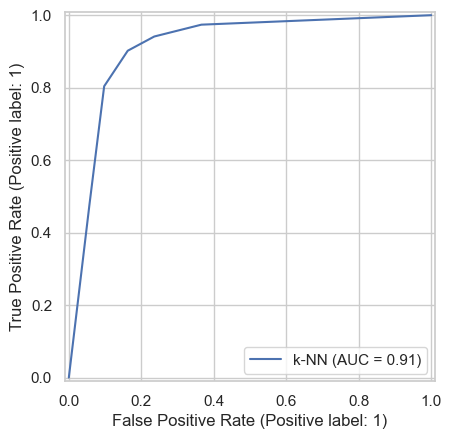

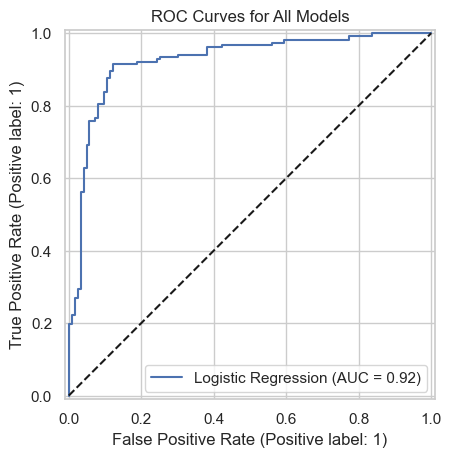

In [17]:
# ROC curves
plt.figure(figsize=(10,7))
for name, (_, y_prob) in models.items():
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name)
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curves for All Models")
plt.show()

## 6. Summary / Conclusion

### Key findings:
1. **Model performance:**
   - Decision Tree: Best recall (0.90) - optimal for disease detection
   - Logistic aRegression: Best F1-score balance (0.88)
   - k-NN: Average performance, sensitive to scaling

2. **Important features:**
   - Oldpeak, MaxHR, ExerciseAngina strongly correlated with the target
   - Sex (M) and ExerciseAngina (Y) significant indicators

3. **Impact of preprocessing:**
   - StandardScaler improves k-NN vs. no scaling
   - OneHotEncoding necessary for categorical variables

### Recommendations:
- **Model to deploy:** Decision Tree (to maximize recall)
- **Possible improvements:**
  * Test Random Forest for robustness
  * Collect more data for rare cases
  * Cross-validation for generalization

### Conclusion:
The project achieves its objective with a recall of 90% on Decision Tree, ensuring effective detection of heart disease cases.